### Statistiques descriptives
Ce notebook produit plusieurs statistiques descriptives sur différentes étapes de nos données (avant, après NLP).

In [38]:
import pandas as pd
pd.options.plotting.backend ='plotly'
import plotly.express as px
import matplotlib.pyplot as plt

In [55]:
# Nombre d'utilisateurs scrapés
df = pd.read_csv('../clean_data/struc_all_interactions.csv')
df['user'].nunique()

1276

In [ ]:
# Nombre d'utilisateurs ayant publié au moins un message à caractère politique 
df_total = pd.read_csv('../clean_data/struct_classified_interactions.csv')
df_total = df_total[df_total["user_political"] == 1]
df_total['user'].nunique()

### Figure 1.a
Nombres d'utilisateurs participant à ce trimestre ou à un trimestre ultérieur à un échange à cractère politique

In [44]:
df_total["date"] = pd.to_datetime(df_total['date'])
df_total["trimestre"] = df_total["date"].dt.to_period("Q")
dernier_trimestre = (
    df_total.groupby("user")["trimestre"]
    .max()
)
trimestres = pd.period_range(
    df_total["trimestre"].min(),
    df_total["trimestre"].max(),
    freq="Q"
)

survie = []

for t in trimestres:
    nb = (dernier_trimestre >= t).sum()
    survie.append({
        "trimestre": t.to_timestamp(),
        "nb_actifs": nb
    })

survie_df = pd.DataFrame(survie)

C:\Users\cfrou\AppData\Local\Temp\ipykernel_44944\3952445522.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_total["trimestre"] = df_total["date"].dt.to_period("Q")


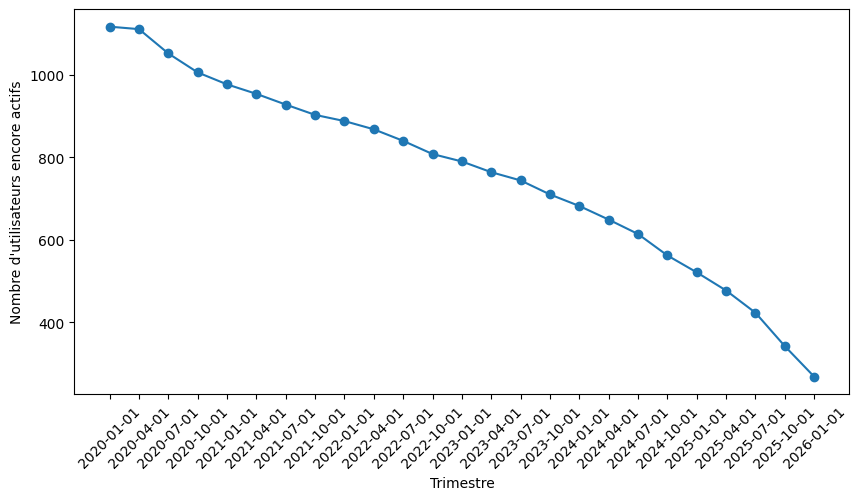

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    survie_df["trimestre"].astype(str),
    survie_df["nb_actifs"]
    ,marker="o"
)

plt.xlabel("Trimestre")
plt.ylabel("Nombre d'utilisateurs encore actifs")
#plt.title("Survie des utilisateurs Reddit")
plt.xticks(rotation=45)
plt.savefig("UtilisateursQ.png")

### Figure 1.b
Nombre d’interaction à caractère politiques par trimestre.

In [46]:
commentaires_trimestre = (
    df_total.groupby("trimestre")
    .size()
    .reset_index(name="nb_commentaires")
)

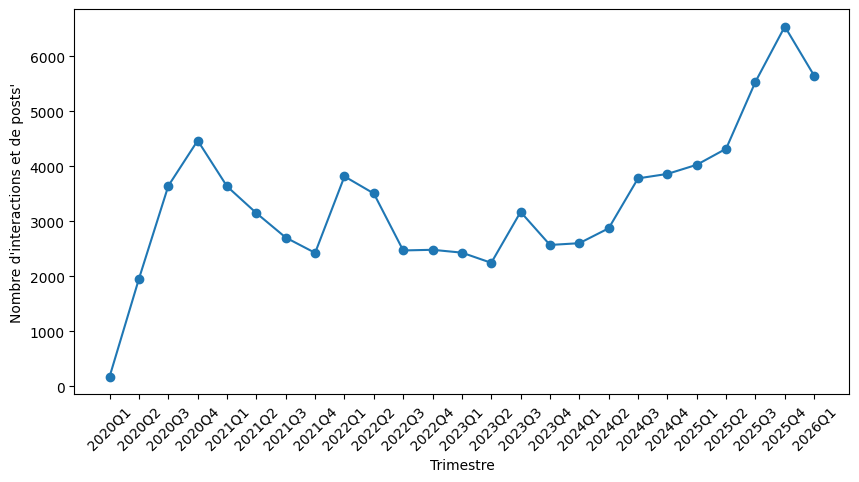

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    commentaires_trimestre["trimestre"].astype(str),
    commentaires_trimestre["nb_commentaires"],
    marker="o"
)

plt.xlabel("Trimestre")
plt.ylabel("Nombre d'interactions et de posts'")
#plt.title("Nombre d'interactions et de posts par trimestre")

plt.xticks(rotation=45)

plt.savefig("CommentairesQ.png")

### Figure 2
Proportion de commentaires violents par trimestre
Notez que la figure produit par le code ci-dessous n'est pas la même que dans le rapport : le rapport affiche la proportion de commentaires labellisés violent par le DistilBERT (4180 messages). Mais cette mesure a été abandonnée par la suite et remplacée par le quatrième quartile du score de toxicité, qui est utilisé dans la cellule ci-dessous. Il serait possible de retrouver la figure du rapport en conservant le label toxique. 

In [48]:
# Proportion de commentaires violent par trimestre
tox_par_trim = (
    df_total.groupby("trimestre")["user_violent"]
    .mean()
    .reset_index(name="proportion_violent")
)

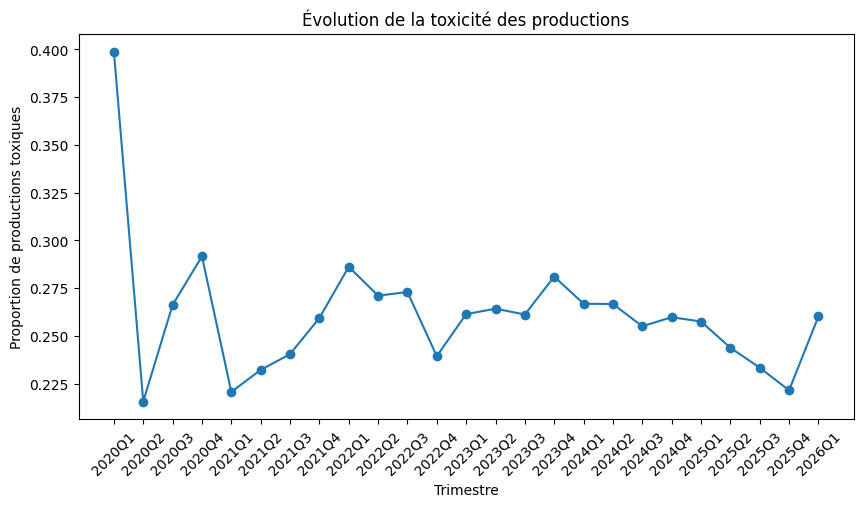

In [50]:
plt.figure(figsize=(10, 5))

plt.plot(
    tox_par_trim["trimestre"].astype(str),
    tox_par_trim["proportion_violent"],
    marker="o"
)

plt.xlabel("Trimestre")
plt.ylabel("Proportion de productions toxiques")
plt.title("Évolution de la toxicité des productions")

#plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.savefig("ProductionsToxiques.png")

### Figure 3.
Proportion d’individus de chaque bord politique par trimestre.

In [51]:
repartition = (
    df_total.groupby(["trimestre", "user_left_right"])
    .size()
    .unstack(fill_value=0)
)

In [52]:
repartition_prop = repartition.div(
    repartition.sum(axis=1),
    axis=0
)

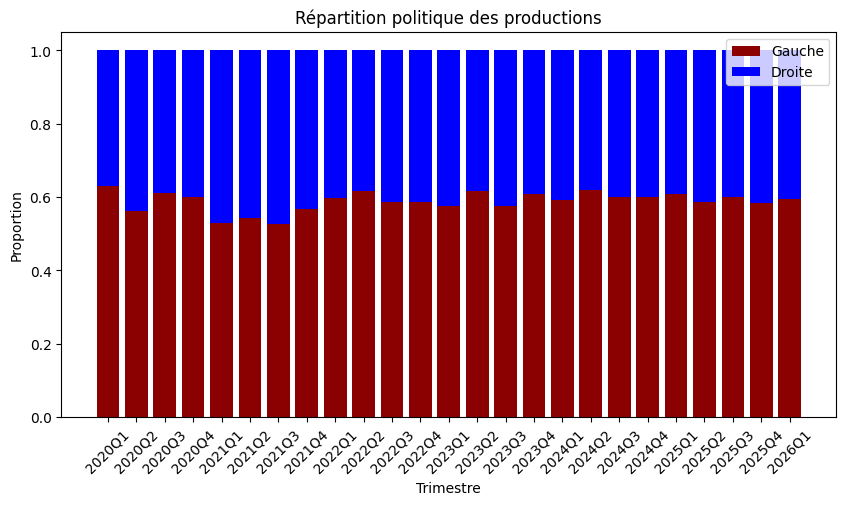

In [53]:

x = repartition_prop.index.astype(str)
gauche = repartition_prop["Left"].values
droite = repartition_prop["Right"].values

plt.figure(figsize=(10, 5))

plt.bar(x, gauche, color='darkred', label="Gauche")
plt.bar(x, droite, bottom=gauche, color='blue', label="Droite")

plt.ylabel("Proportion")
plt.xlabel("Trimestre")
plt.title("Répartition politique des productions")

plt.legend()
plt.xticks(rotation=45)

plt.show()